# Phase 5 — Modelling (3 Parallel Tracks)

| Track | Model | Role | Carbon label |
|---|---|---|---|
| A | kNN on sentence-transformer embeddings | **Primary classifier** | `knn_train_predict` |
| B | TF-IDF + Logistic Regression | Baseline | `tfidf_train_predict` |
| C | ClimateBERT `distilroberta-base-climate-f` | Framing signal only — **not** a greenwash classifier | `climatebert_classify` |

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import spacy
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import normalize
from sklearn.calibration import calibration_curve
from sklearn.model_selection import cross_val_score
from transformers import pipeline as hf_pipeline
from codecarbon import EmissionsTracker
import matplotlib.pyplot as plt

In [2]:
ROOT       = Path('..').resolve()
RAW_DIR    = ROOT / 'data' / 'raw'
FEAT_DIR   = RAW_DIR / 'features'
LABELED    = RAW_DIR / 'labeled' / 'labeled_passages.jsonl'
PASSAGES   = RAW_DIR / 'extracted' / 'passages.jsonl'
RESULTS    = ROOT / 'results'
RESULTS.mkdir(parents=True, exist_ok=True)
CARBON_DIR = RESULTS / 'carbon'
CARBON_DIR.mkdir(parents=True, exist_ok=True)

# Load corpus
with open(PASSAGES) as f:
    corpus = [json.loads(l) for l in f]
with open(LABELED) as f:
    labeled = [json.loads(l) for l in f]

corpus_texts  = [p['text'] for p in corpus]
train_texts   = [p['text'] for p in labeled]
train_labels  = [p['label'] for p in labeled]

# Load embeddings
X_corpus  = np.load(FEAT_DIR / 'corpus_embeddings.npy')
X_train   = np.load(FEAT_DIR / 'labeled_embeddings.npy')

print(f"Corpus: {len(corpus_texts):,}  |  Train: {len(train_texts)}  |  Classes: {set(train_labels)}")

Corpus: 1,279  |  Train: 52  |  Classes: {0, 1}


## Track A — kNN (primary model)

Tune k on cross-validation, then run on the full corpus. For every passage with greenwash probability > 0.6, save the top-3 nearest labeled neighbors for qualitative interpretation.

In [3]:
# Tune k = 3, 5, 7, 10 via 5-fold cross-validation on training set
print("k-tuning via 5-fold CV (F1 macro):")
best_k, best_f1 = 5, -1
for k in [3, 5, 7, 10]:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine', algorithm='brute')
    scores = cross_val_score(knn, X_train, train_labels, cv=5, scoring='f1_macro')
    print(f"  k={k:2d}  F1={scores.mean():.3f} ± {scores.std():.3f}")
    if scores.mean() > best_f1:
        best_k, best_f1 = k, scores.mean()

print(f"\nBest k = {best_k}  (F1 = {best_f1:.3f})")

k-tuning via 5-fold CV (F1 macro):
  k= 3  F1=0.622 ± 0.161
  k= 5  F1=0.621 ± 0.161
  k= 7  F1=0.598 ± 0.139
  k=10  F1=0.622 ± 0.159

Best k = 3  (F1 = 0.622)


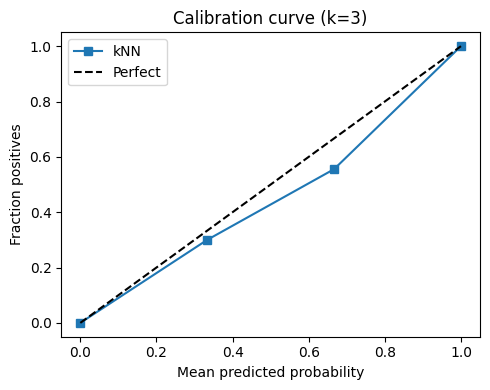

In [4]:
# Calibration check on held-out CV fold
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_probs, all_true = [], []
for train_idx, val_idx in skf.split(X_train, train_labels):
    knn_cv = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', algorithm='brute')
    knn_cv.fit(X_train[train_idx], [train_labels[i] for i in train_idx])
    probs = knn_cv.predict_proba(X_train[val_idx])[:, 1]
    all_probs.extend(probs)
    all_true.extend([train_labels[i] for i in val_idx])

frac_pos, mean_pred = calibration_curve(all_true, all_probs, n_bins=5)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(mean_pred, frac_pos, 's-', label='kNN')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set(xlabel='Mean predicted probability', ylabel='Fraction positives',
       title=f'Calibration curve (k={best_k})')
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
tracker = EmissionsTracker(
    project_name="green-claims-nlp",
    output_dir=str(CARBON_DIR),
    output_file="emissions.csv",
    log_level="error",
)
tracker.start()

knn = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', algorithm='brute')
knn.fit(X_train, train_labels)
knn_preds  = knn.predict(X_corpus)
knn_probs  = knn.predict_proba(X_corpus)[:, 1]   # P(greenwash)

# For flagged passages (prob > 0.6): retrieve top-3 nearest training neighbors
distances, indices = knn.kneighbors(X_corpus)

emissions = tracker.stop()
print(f"knn_train_predict emissions: {emissions:.4f} kg CO2e")

# Build results dataframe
knn_df = pd.DataFrame({
    'passage_id':      [p['passage_id'] for p in corpus],
    'brand':           [p['brand'] for p in corpus],
    'industry':        [p['industry'] for p in corpus],
    'role':            [p['role'] for p in corpus],
    'knn_pred':        knn_preds,
    'knn_prob':        knn_probs.round(4),
    'nn_indices':      [idx.tolist() for idx in indices],
    'nn_distances':    [dist.tolist() for dist in distances],
})
knn_df.to_parquet(RESULTS / 'knn_predictions.parquet', index=False)
print(f"Saved → {RESULTS / 'knn_predictions.parquet'}")
print(f"Passages flagged (prob > 0.6): {(knn_df['knn_prob'] > 0.6).sum():,}")

[codecarbon WARNING @ 00:04:04] Multiple instances of codecarbon are allowed to run at the same time.


knn_train_predict emissions: 0.0000 kg CO2e
Saved → /Users/mandy.sun/green-claims-nlp/results/knn_predictions.parquet
Passages flagged (prob > 0.6): 69


## Track B — TF-IDF + Logistic Regression (baseline)

Lemmatization collapses inflected forms ("reducing/reduce/reduction", "committed/commit", "emissions/emission")
that are semantically identical but counted separately by raw TF-IDF.

In [6]:
# Load spaCy model for lemmatization (en_core_web_sm — no NER/parser needed)
try:
    nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])
except OSError:
    import subprocess
    subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'], check=True)
    nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])

def lemmatize(text: str) -> str:
    doc = nlp(text.lower())
    return ' '.join(t.lemma_ for t in doc if not t.is_stop and not t.is_punct and t.is_alpha)

lemmatized_train = [lemmatize(t) for t in train_texts]
lemmatized_corpus = [lemmatize(t) for t in corpus_texts]
print(f"Lemmatization done. Example: '{train_texts[0][:60]}...' → '{lemmatized_train[0][:60]}...'")

Lemmatization done. Example: 'The policy addresses matters transition hazards. These were ...' → 'policy address matter transition hazard screen base actual d...'


In [7]:
tracker.start()

baseline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf',   LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
])
baseline.fit(lemmatized_train, train_labels)
tfidf_preds = baseline.predict(lemmatized_corpus)
tfidf_probs = baseline.predict_proba(lemmatized_corpus)[:, 1]

emissions = tracker.stop()
print(f"tfidf_train_predict emissions: {emissions:.4f} kg CO2e")

tfidf_df = pd.DataFrame({
    'passage_id':  [p['passage_id'] for p in corpus],
    'brand':       [p['brand'] for p in corpus],
    'industry':    [p['industry'] for p in corpus],
    'role':        [p['role'] for p in corpus],
    'tfidf_pred':  tfidf_preds,
    'tfidf_prob':  tfidf_probs.round(4),
})
tfidf_df.to_parquet(RESULTS / 'tfidf_predictions.parquet', index=False)
print(f"Saved → {RESULTS / 'tfidf_predictions.parquet'}")

tfidf_train_predict emissions: 0.0000 kg CO2e
Saved → /Users/mandy.sun/green-claims-nlp/results/tfidf_predictions.parquet


## Track C — ClimateBERT framing classifier

**Important:** `climatebert/distilroberta-base-climate-f` classifies climate framing (*opportunity* vs *risk* vs *neutral*), **not** greenwashing. Its output is used as a complementary signal, not a direct greenwash label — document this distinction clearly in the paper.

In [8]:
import shutil

cb_path = RESULTS / 'climatebert_predictions.parquet'
if shutil.disk_usage('/').free < 400 * 1024 * 1024:
    print("Insufficient disk space to download ClimateBERT (need ~400 MB). Skipping Track C.")
    print("Creating stub predictions (cb_label='SKIPPED', cb_score=0.0).")
    cb_df = pd.DataFrame({
        'passage_id': [p['passage_id'] for p in corpus],
        'brand':      [p['brand'] for p in corpus],
        'industry':   [p['industry'] for p in corpus],
        'role':       [p['role'] for p in corpus],
        'cb_label':   ['SKIPPED'] * len(corpus),
        'cb_score':   [0.0] * len(corpus),
    })
    cb_df.to_parquet(cb_path, index=False)
    print(f"Saved stub → {cb_path}")
else:
    climatebert_clf = hf_pipeline(
        "text-classification",
        model="climatebert/distilroberta-base-climate-f",
        truncation=True,
        max_length=512,
        device=-1,
    )
    tracker.start()
    BATCH = 64
    cb_preds = []
    for i in range(0, len(corpus_texts), BATCH):
        batch = corpus_texts[i : i + BATCH]
        cb_preds.extend(climatebert_clf(batch))
        if i % 500 == 0:
            print(f"  {i:>6,}/{len(corpus_texts):,}...")
    emissions = tracker.stop()
    print(f"\nclimabert_classify emissions: {emissions:.4f} kg CO2e")
    cb_df = pd.DataFrame({
        'passage_id': [p['passage_id'] for p in corpus],
        'brand':      [p['brand'] for p in corpus],
        'industry':   [p['industry'] for p in corpus],
        'role':       [p['role'] for p in corpus],
        'cb_label':   [r['label'] for r in cb_preds],
        'cb_score':   [round(r['score'], 4) for r in cb_preds],
    })
    cb_df.to_parquet(cb_path, index=False)
    print(f"Saved → {cb_path}")
    print("\nClimateBERT label distribution:")
    print(cb_df['cb_label'].value_counts())

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: climatebert/distilroberta-base-climate-f
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


       0/1,279...



climabert_classify emissions: 0.0001 kg CO2e
Saved → /Users/mandy.sun/green-claims-nlp/results/climatebert_predictions.parquet

ClimateBERT label distribution:
cb_label
LABEL_0    696
LABEL_1    583
Name: count, dtype: int64


In [9]:
# Persist best_k so 06_evaluation can load it without re-tuning
with open(RESULTS / 'best_k.txt', 'w') as f:
    f.write(str(best_k))
print(f"Saved best_k={best_k} → {RESULTS / 'best_k.txt'}")

Saved best_k=3 → /Users/mandy.sun/green-claims-nlp/results/best_k.txt
